# Simulate ICSat-2 data for 1985 - 2021: 
### using sampled reanalysis data and daily icesat2 error statistics

In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import altair as alt

In [2]:
sierras = gpd.read_file('../data/misc/sierra_simplified.geojson')

In [3]:
atl06sr_gdf = pickle.load(open('../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked_fscapresence.pkl', 'rb'))
atl06sr_gdf = atl06sr_gdf.clip(sierras.to_crs(atl06sr_gdf.crs))
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [4]:
atl06sr_gdf_snowy = atl06sr_gdf[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']<20)].copy()
atl06sr_gdf_snowy['n'] = atl06sr_gdf_snowy.groupby('acqdate')['acqdate'].transform('count')

In [5]:
atl06sr_gdf_snowy_100 = atl06sr_gdf_snowy[atl06sr_gdf_snowy['n']>100].copy()

In [6]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [7]:
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs.rio.clip(sierras.geometry)

In [8]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_sierras.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 4) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 1) ))
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5
# 4. Apply mask
swe_sca_ds_allyrs_roi = swe_sca_ds_allyrs_sierras.where(mask)

### Check the ICESat-2 tracks around april 1:

In [16]:
date_of_interest = pd.Timestamp('2019-04-01')


2019:
  Number of points: 36245
  Number of unique dates: 6
  Date range: 2019-03-21 00:00:00 to 2019-04-15 00:00:00


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_16032/565170365.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_dates))



2020:
  Number of points: 37221
  Number of unique dates: 5
  Date range: 2020-04-03 00:00:00 to 2020-04-15 00:00:00


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_16032/565170365.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_dates))



2021:
  Number of points: 46473
  Number of unique dates: 6
  Date range: 2021-04-01 00:00:00 to 2021-04-15 00:00:00


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_16032/565170365.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_dates))


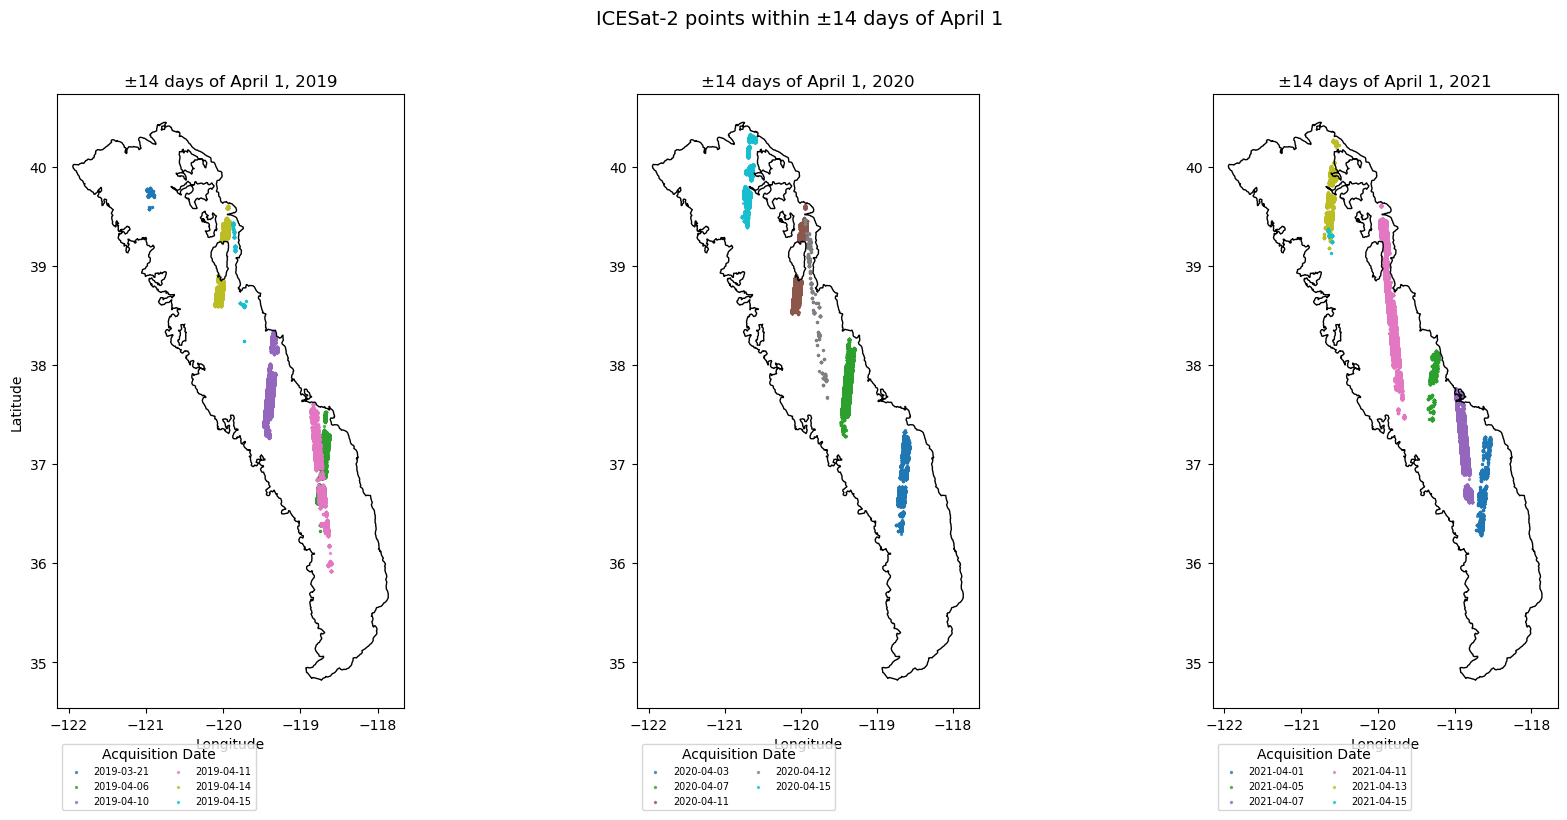

In [46]:
# Define target dates and window
target_dates = [
    pd.Timestamp('2019-04-01'),
    pd.Timestamp('2020-04-01'),
    pd.Timestamp('2021-04-01')
]
window_days = 14

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for idx, target_date in enumerate(target_dates):
    ax = axes[idx]
    
    # Subset to dates within two weeks centered on target date
    start_date = target_date - pd.Timedelta(days=window_days)
    end_date = target_date + pd.Timedelta(days=window_days)
    
    atl06sr_subset_plot = atl06sr_gdf_snowy_100[
        (atl06sr_gdf_snowy_100['acqdate_dt'] >= start_date) & 
        (atl06sr_gdf_snowy_100['acqdate_dt'] <= end_date)
    ].copy()
    
    # Print stats
    print(f"\n{target_date.year}:")
    print(f"  Number of points: {len(atl06sr_subset_plot)}")
    print(f"  Number of unique dates: {atl06sr_subset_plot['acqdate_dt'].nunique()}")
    print(f"  Date range: {atl06sr_subset_plot['acqdate_dt'].min()} to {atl06sr_subset_plot['acqdate_dt'].max()}")
    
    # Get unique dates and create a colormap
    unique_dates = sorted(atl06sr_subset_plot['acqdate_dt'].unique())
    cmap = plt.cm.get_cmap('tab10', len(unique_dates))
    
    # Plot sierras boundary
    sierras.boundary.plot(ax=ax, color='black', linewidth=1)
    
    # Plot each date with a different color
    for i, date in enumerate(unique_dates):
        subset = atl06sr_subset_plot[atl06sr_subset_plot['acqdate_dt'] == date]
        date_str = pd.Timestamp(date).strftime('%Y-%m-%d')
        subset.plot(ax=ax, markersize=2, alpha=0.7, color=cmap(i), label=date_str)
    
    ax.set_title(f'±{window_days} days of April 1, {target_date.year}')
    ax.set_xlabel('Longitude')
    if idx == 0:
        ax.set_ylabel('Latitude')
    ax.legend(title='Acquisition Date', loc='upper left', bbox_to_anchor=(0.0, -0.05), 
              fontsize=7, ncol=2)

plt.suptitle('ICESat-2 points within ±14 days of April 1', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [28]:
atl06sr_gdf_snowy_100


,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,reanalysis_sca,reanalysis_sd,icesat2_3dep_dif,dif_plus,offset_sd,mask,snow_presence,snow_presence_fsca,acqdate_dt,n
time_ns,,,,,,,,,,,,,,,,,,,,,
2021-05-06 02:44:13.409649664,0.0,1.0,0,2469.806340,2,19.091114,60,18,3.000000,223338299392,...,0.0,0.0,-1.119573,-1.064844,-1.064844,1,1,0,2021-05-06,6899
2021-05-06 02:44:13.418056960,0.0,1.0,0,2466.017802,2,14.589265,60,12,3.000000,223338299392,...,0.0,0.0,-2.352763,-2.298034,-2.298034,1,1,0,2021-05-06,6899
2021-05-06 02:44:13.420872448,0.0,1.0,0,2463.521107,2,15.121697,60,28,3.021712,223338299392,...,0.0,0.0,-0.206410,-0.151681,-0.151681,1,1,0,2021-05-06,6899
2021-05-06 02:44:13.423703808,0.0,1.0,0,2463.309079,2,14.034070,60,27,3.547080,223338299392,...,0.0,0.0,-1.821286,-1.766557,-1.766557,1,1,0,2021-05-06,6899
2021-05-06 02:44:13.426540032,0.0,1.0,0,2461.340214,2,13.435073,60,32,3.000000,223338299392,...,0.0,0.0,-1.319706,-1.264978,-1.264978,1,1,0,2021-05-06,6899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-13 08:53:50.912035840,0.0,1.0,0,1742.818328,6,12.960171,20,14,6.548101,223338299392,...,0.0,0.0,-1.291839,-1.237110,-1.237110,1,0,0,2021-09-13,2660
2021-09-13 08:53:50.906396416,0.0,1.0,0,1734.065649,6,12.472521,20,19,4.875024,223338299392,...,0.0,0.0,-1.239721,-1.184992,-1.184992,1,0,0,2021-09-13,2660
2021-09-13 08:53:50.903582976,0.0,1.0,0,1729.802896,6,10.547972,20,19,4.129656,223338299392,...,0.0,0.0,-0.394693,-0.339964,-0.339964,1,0,0,2021-09-13,2660


### Characterize ICESat-2 error compared to reanalysis for dates within 1 March - 31 May:

In [11]:
# Expand error calculation to snowy dates in atl06sr_gdf_snowy_100
# Filter to dates within March 1 to May 31

print("Calculating error statistics from snowy dates (2018-2021)...")
print(f"Filtering to dates within March 1 - May 31")

# Filter to spring season (March 1 to May 31)
gdf_spring = atl06sr_gdf_snowy_100[
    (atl06sr_gdf_snowy_100['acqdate_dt'].dt.month >= 3) & 
    (atl06sr_gdf_snowy_100['acqdate_dt'].dt.month <= 5)
].copy()
print(f"Points in Mar-May: {len(gdf_spring)} ({100*len(gdf_spring)/len(atl06sr_gdf_snowy_100):.1f}%)")

# Group by date and compute medians for ICESat-2 and reanalysis
error_df_all = gdf_spring.groupby(gdf_spring['acqdate_dt'].dt.date).agg(
    is2_median=('icesat2_3dep_dif', 'median'),
    reanalysis_median=('reanalysis_sd', 'median'),
    n_points=('icesat2_3dep_dif', 'count'),
    point_error_std=('icesat2_3dep_dif', lambda x: (gdf_spring.loc[x.index, 'icesat2_3dep_dif'] - 
                                                     gdf_spring.loc[x.index, 'reanalysis_sd']).std())
).reset_index()

error_df_all.columns = ['date', 'is2_median', 'reanalysis_median', 'n_points', 'point_error_std']
error_df_all['date'] = pd.to_datetime(error_df_all['date'])
error_df_all['error_median'] = error_df_all['is2_median'] - error_df_all['reanalysis_median']
error_df_all = error_df_all.sort_values('date')

print(f"\nTotal unique dates: {len(error_df_all)}")
print(f"Date range: {error_df_all['date'].min().date()} to {error_df_all['date'].max().date()}")

Calculating error statistics from snowy dates (2018-2021)...
Filtering to dates within March 1 - May 31
Points in Mar-May: 369181 (25.5%)

Total unique dates: 63
Date range: 2019-03-04 to 2021-05-29


ERROR STATISTICS (from ALL snowy dates, 2018-2021)

Based on daily MEDIAN errors (63 dates):
  Median Bias: 0.044 m
  Std of Median Error: 0.210 m
  MAE of Median Error: 0.163 m
  Min/Max Median Error: -0.555 / 0.480 m

Point-level error spread (avg within-date std): 1.194 m

Comparison to April ±14 days only:
  Previous bias: -0.084 m  |  All-date bias: 0.044 m
  Previous std:  0.331 m  |  All-date std:  0.210 m


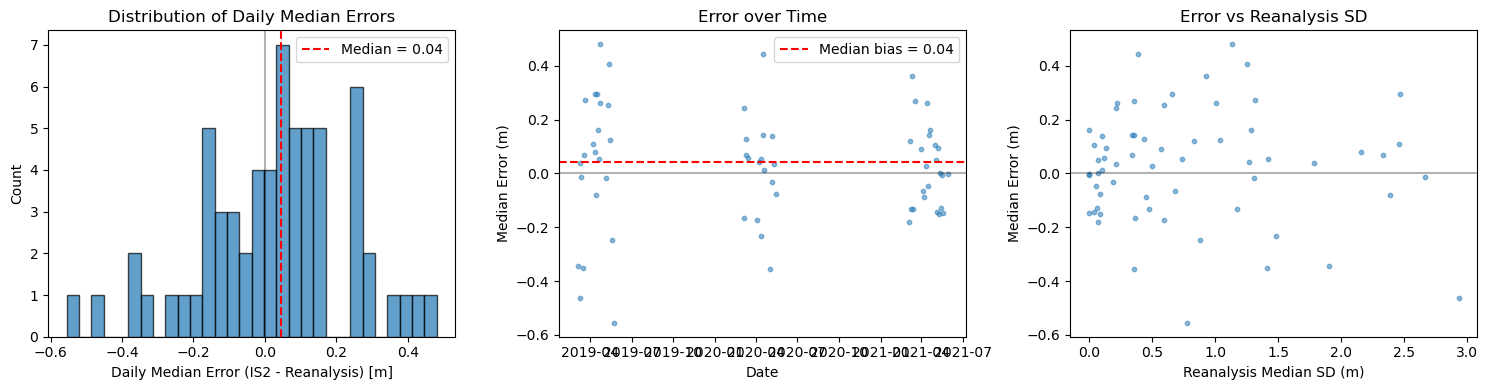


→ Using robust estimates: bias=0.044 m, std=0.210 m


In [30]:
# Calculate robust error statistics from 1 March - 31 May dates
bias_all = error_df_all['error_median'].median()
std_error_all = error_df_all['error_median'].std()
mae_all = error_df_all['error_median'].abs().mean()

# Also compute from point-level errors (pooled across dates)
mean_point_std = error_df_all['point_error_std'].mean()

print("=" * 60)
print("ERROR STATISTICS (from ALL snowy dates, 2018-2021)")
print("=" * 60)
print(f"\nBased on daily MEDIAN errors ({len(error_df_all)} dates):")
print(f"  Median Bias: {bias_all:.3f} m")
print(f"  Std of Median Error: {std_error_all:.3f} m")
print(f"  MAE of Median Error: {mae_all:.3f} m")
print(f"  Min/Max Median Error: {error_df_all['error_median'].min():.3f} / {error_df_all['error_median'].max():.3f} m")

print(f"\nPoint-level error spread (avg within-date std): {mean_point_std:.3f} m")

# Compare to previous (April 1 window only)
print(f"\nComparison to April ±14 days only:")
print(f"  Previous bias: {bias:.3f} m  |  All-date bias: {bias_all:.3f} m")
print(f"  Previous std:  {std_error:.3f} m  |  All-date std:  {std_error_all:.3f} m")

# Plot error distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of median errors
axes[0].hist(error_df_all['error_median'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(bias_all, color='red', linestyle='--', label=f'Median = {bias_all:.2f}')
axes[0].axvline(0, color='black', linestyle='-', alpha=0.3)
axes[0].set_xlabel('Daily Median Error (IS2 - Reanalysis) [m]')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Daily Median Errors')
axes[0].legend()

# Time series of errors
axes[1].scatter(error_df_all['date'], error_df_all['error_median'], alpha=0.5, s=10)
axes[1].axhline(bias_all, color='red', linestyle='--', label=f'Median bias = {bias_all:.2f}')
axes[1].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Median Error (m)')
axes[1].set_title('Error over Time')
axes[1].legend()

# Error vs reanalysis SD (check for heteroscedasticity)
axes[2].scatter(error_df_all['reanalysis_median'], error_df_all['error_median'], alpha=0.5, s=10)
axes[2].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[2].set_xlabel('Reanalysis Median SD (m)')
axes[2].set_ylabel('Median Error (m)')
axes[2].set_title('Error vs Reanalysis SD')

plt.tight_layout()
plt.show()

# Update global variables with robust estimates
bias_robust = bias_all
std_error_robust = std_error_all
print(f"\n→ Using robust estimates: bias={bias_robust:.3f} m, std={std_error_robust:.3f} m")

### Sample Reanalysis at ICESat-2 points for Cherry Picked Dates and Times:

Cherry picked tracks:
'2020-04-03'        
'2020-04-07'        > pretend this happened on 04-01 (to match 2021 timing)
'2020-04-11'        > pretend this happened on 04-05 (to match 2021 timing)

'2021-04-07'
'2021-04-11'
'2021-04-13'


In [16]:
# Select specific cherry-picked dates
selected_dates = [
    '2020-04-03',
    '2020-04-07',
    '2020-04-11',
    '2021-04-07',
    '2021-04-11',
    '2021-04-13'
]
selected_dates = pd.to_datetime(selected_dates)

# Subset to selected dates
atl06sr_subset = atl06sr_gdf_snowy_100[
    atl06sr_gdf_snowy_100['acqdate_dt'].isin(selected_dates)
].copy()

# Create adjusted date column (for reanalysis sampling)
# Adjust specific dates and convert all to year 2021
date_adjustments = {
    pd.Timestamp('2020-04-03'): pd.Timestamp('2021-04-03'),
    pd.Timestamp('2020-04-07'): pd.Timestamp('2021-04-01'),
    pd.Timestamp('2020-04-11'): pd.Timestamp('2021-04-05'),
}
# First apply specific adjustments, then convert all to year 2021
atl06sr_subset['adjusted_date'] = atl06sr_subset['acqdate_dt'].map(
    lambda x: date_adjustments.get(x, x)
).apply(lambda x: x.replace(year=2021))

print(f"Selected dates: {[d.strftime('%Y-%m-%d') for d in selected_dates]}")
print(f"Unique dates in subset: {atl06sr_subset['acqdate_dt'].dt.date.nunique()}")
print(f"Total points: {len(atl06sr_subset)}")
print(f"\nDate adjustments:")
for orig, adj in date_adjustments.items():
    print(f"  {orig.strftime('%Y-%m-%d')} → {adj.strftime('%Y-%m-%d')}")
print(f"\nAdjusted dates: {sorted(atl06sr_subset['adjusted_date'].dt.date.unique())}")

Selected dates: ['2020-04-03', '2020-04-07', '2020-04-11', '2021-04-07', '2021-04-11', '2021-04-13']
Unique dates in subset: 6
Total points: 70070

Date adjustments:
  2020-04-03 → 2021-04-03
  2020-04-07 → 2021-04-01
  2020-04-11 → 2021-04-05

Adjusted dates: [datetime.date(2021, 4, 1), datetime.date(2021, 4, 3), datetime.date(2021, 4, 5), datetime.date(2021, 4, 7), datetime.date(2021, 4, 11), datetime.date(2021, 4, 13)]


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_16032/2150352202.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_dates))


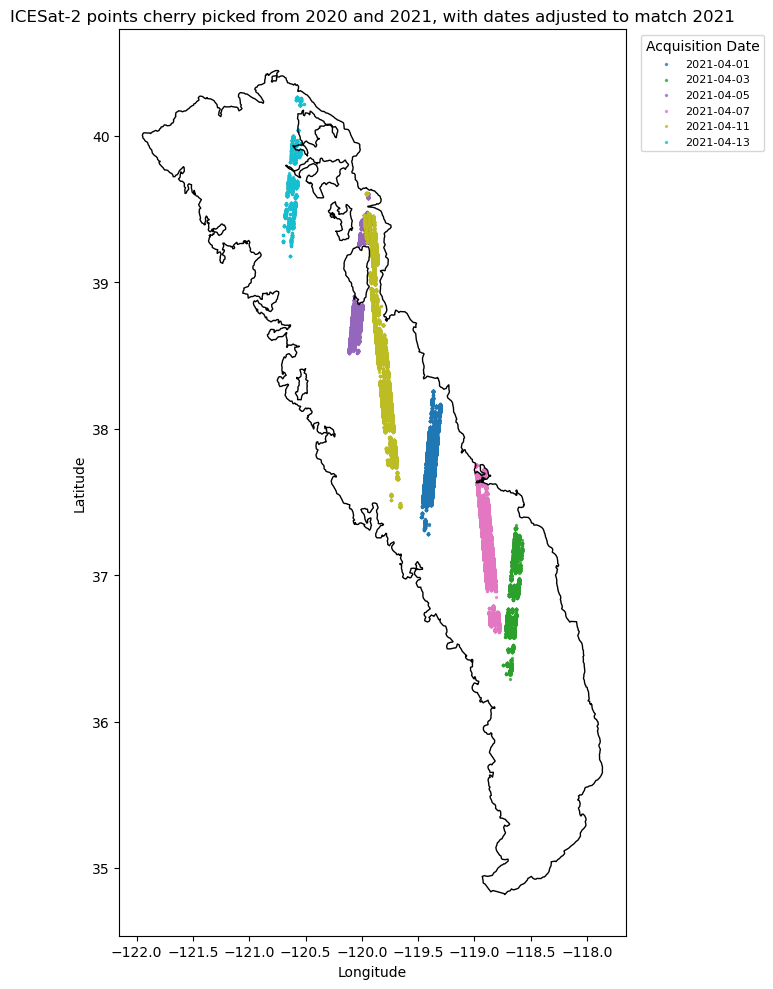

In [49]:


# Get unique dates and create a colormap
unique_dates = sorted(atl06sr_subset['adjusted_date'].unique())
cmap = plt.cm.get_cmap('tab10', len(unique_dates))

# Plot spatial location with sierras polygon, colored by date
fig, ax = plt.subplots(figsize=(10, 10))
sierras.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot each date with a different color
for i, date in enumerate(unique_dates):
    subset = atl06sr_subset[atl06sr_subset['adjusted_date'] == date]
    date_str = pd.Timestamp(date).strftime('%Y-%m-%d')
    subset.plot(ax=ax, markersize=2, alpha=0.7, color=cmap(i), label=date_str)

ax.set_title(f'ICESat-2 points cherry picked from 2020 and 2021, with dates adjusted to match 2021')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Acquisition Date', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

In [34]:
# Sample reanalysis snow depth data using ADJUSTED dates for historical lookup
# Group by original acqdate but use adjusted_date for the actual reanalysis date

unique_acq_dates = atl06sr_subset['acqdate_dt'].dt.date.unique()

for year in range(1985, 2022):
    # Initialize column with NaN
    atl06sr_subset[f'wy_{year}'] = np.nan
    
    for acq_date in unique_acq_dates:
        # Get points for this acquisition date
        mask = atl06sr_subset['acqdate_dt'].dt.date == acq_date
        lons = atl06sr_subset.loc[mask, 'geometry'].x.values
        lats = atl06sr_subset.loc[mask, 'geometry'].y.values
        
        # Get the adjusted date for this acquisition date (for reanalysis lookup)
        adjusted_date = atl06sr_subset.loc[mask, 'adjusted_date'].iloc[0]
        
        # Get the equivalent date in the historical year using ADJUSTED month/day
        target_date = pd.Timestamp(f'{year}-{adjusted_date.month:02d}-{adjusted_date.day:02d}')
        
        # Select the snow depth data for this target date
        sd_on_date = swe_sca_ds_allyrs_roi['SD_Post'].sel(time=target_date, method='nearest')
        
        # Sample at ICESat-2 points using linear interpolation
        sampled_sd = sd_on_date.interp(
            x=xr.DataArray(lons, dims='points'),
            y=xr.DataArray(lats, dims='points'),
            method='linear'
        ).values
        
        # Assign to the subset
        atl06sr_subset.loc[mask, f'wy_{year}'] = sampled_sd

print(f"Subset dataframe shape: {atl06sr_subset.shape}")
print(f"Unique acquisition dates: {sorted(unique_acq_dates)}")
print(f"Columns added: {[col for col in atl06sr_subset.columns if 'wy_' in col]}")

Subset dataframe shape: (70070, 88)
Unique acquisition dates: [datetime.date(2020, 4, 3), datetime.date(2020, 4, 7), datetime.date(2020, 4, 11), datetime.date(2021, 4, 7), datetime.date(2021, 4, 11), datetime.date(2021, 4, 13)]
Columns added: ['wy_1985', 'wy_1986', 'wy_1987', 'wy_1988', 'wy_1989', 'wy_1990', 'wy_1991', 'wy_1992', 'wy_1993', 'wy_1994', 'wy_1995', 'wy_1996', 'wy_1997', 'wy_1998', 'wy_1999', 'wy_2000', 'wy_2001', 'wy_2002', 'wy_2003', 'wy_2004', 'wy_2005', 'wy_2006', 'wy_2007', 'wy_2008', 'wy_2009', 'wy_2010', 'wy_2011', 'wy_2012', 'wy_2013', 'wy_2014', 'wy_2015', 'wy_2016', 'wy_2017', 'wy_2018', 'wy_2019', 'wy_2020', 'wy_2021']


In [36]:
atl06sr_subset.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy', 'acqdate', 'reanalysis_swe',
       'reanalysis_sca', 'reanalysis_sd', 'icesat2_3dep_dif', 'dif_plus',
       'offset_sd', 'mask', 'snow_presence', 'snow_presence_fsca',
       'acqdate_dt', 'n', 'adjusted_date', 'wy_1985', 'wy_1986', 'wy_1987',
       'wy_1988', 'wy_1989', 'wy_1990', 'wy_1991', 'wy_1992', 'wy_1993',
       'wy_1994', 'wy_1995', 'wy_1996', 'wy_1997', 'wy_1998', 'wy_1999',
       'wy_2000', 'wy_2001', 'wy_2002', 'wy_2003', 'wy_2004'

In [47]:
# Convert all adjusted_date values to year 2021 (keeping month and day)
atl06sr_subset['adjusted_date'] = atl06sr_subset['adjusted_date'].apply(lambda x: x.replace(year=2021))
print(f"Adjusted dates now: {sorted(atl06sr_subset['adjusted_date'].dt.date.unique())}")

Adjusted dates now: [datetime.date(2021, 4, 1), datetime.date(2021, 4, 3), datetime.date(2021, 4, 5), datetime.date(2021, 4, 7), datetime.date(2021, 4, 11), datetime.date(2021, 4, 13)]


### Save these sampled values before adding in error statistics

In [48]:
atl06sr_subset.to_pickle('../data/icesat2/sampled_reanalysis_cherrypicked_tracks.pkl')

### Add Error statistics to sampled reanalysis cherry picked dates, making a new df and adding in the bias thats been sampled from the daily distribution:

In [62]:
# Step 1: Make a dataframe with median ICESat-2 SD and median reanalysis SD for each date
wy_cols = [col for col in atl06sr_subset.columns if col.startswith('wy_')]

# Group by date and compute medians
medians_by_date = atl06sr_subset.groupby(atl06sr_subset['adjusted_date'].dt.date).agg(
    icesat2_median=('icesat2_3dep_dif', 'median'),
    **{col: (col, 'median') for col in wy_cols}
).reset_index()
medians_by_date.columns = ['adjusted_date', 'icesat2_median'] + wy_cols  
medians_by_date['date'] = pd.to_datetime(medians_by_date['adjusted_date'])
medians_by_date = medians_by_date.sort_values('adjusted_date')

print(f"Medians by date shape: {medians_by_date.shape}")
medians_by_date

Medians by date shape: (6, 40)


,adjusted_date,icesat2_median,wy_1985,wy_1986,wy_1987,wy_1988,wy_1989,wy_1990,wy_1991,wy_1992,...,wy_2013,wy_2014,wy_2015,wy_2016,wy_2017,wy_2018,wy_2019,wy_2020,wy_2021,date
0,2021-04-01,1.312578,1.924723,2.634298,1.223753,0.644560,1.618922,0.600869,1.817257,1.509542,...,0.933749,0.836948,0.005416,1.328366,2.975773,1.051612,2.558728,0.961402,1.049550,2021-04-01
1,2021-04-03,0.426210,1.653203,2.350982,0.935556,0.424587,1.058059,0.478602,1.831300,1.171965,...,0.512805,0.520155,0.002623,0.956427,2.218288,0.848167,2.433185,0.666460,0.501251,2021-04-03
2,2021-04-05,1.251126,1.407565,2.180916,0.796316,0.383399,1.414029,0.802161,1.655303,0.791767,...,0.787259,0.943277,0.013963,1.417630,2.660225,0.860548,2.933871,1.431876,0.961917,2021-04-05
3,2021-04-07,0.365464,1.426223,2.833164,0.958263,0.400653,0.977605,0.393353,1.611680,1.234875,...,0.482345,0.565129,0.009664,0.940655,2.423286,0.871148,2.424826,1.139036,0.530330,2021-04-07
4,2021-04-11,0.529329,0.976529,1.977536,0.543480,0.165229,0.653596,0.386917,1.293431,0.507595,...,0.572349,0.401742,0.013402,1.084802,2.543346,0.508279,2.324096,1.214001,0.549287,2021-04-11
5,2021-04-13,0.485709,0.834045,1.132305,0.321477,0.176122,0.649324,0.313260,1.183276,0.458485,...,0.190795,0.014175,0.000000,0.739188,1.959586,0.352915,1.886201,0.868283,0.412558,2021-04-13


In [ ]:
# # Step 2: Calculate error statistics between ICESat-2 and reanalysis (WY 2019 as reference)
# # Using the contemporaneous year (2019) to characterize ICESat-2 vs reanalysis differences

# # Calculate daily errors: ICESat-2 median - Reanalysis median
# medians_by_date['error_2019'] = medians_by_date['icesat2_median'] - medians_by_date['wy_2019']

# # Error statistics across days
# bias = medians_by_date['error_2019'].median()  # Systematic bias
# std_error = medians_by_date['error_2019'].std()  # Random error spread
# mae = medians_by_date['error_2019'].abs().mean()  # Mean absolute error

# print("Error Statistics (ICESat-2 - Reanalysis, based on daily medians):")
# print(f"  Median Bias: {bias:.3f} m")
# print(f"  Std of Error: {std_error:.3f} m")
# print(f"  MAE: {mae:.3f} m")
# print(f"  Min Error: {medians_by_date['error_2019'].min():.3f} m")
# print(f"  Max Error: {medians_by_date['error_2019'].max():.3f} m")

Error Statistics (ICESat-2 - Reanalysis, based on daily medians):
  Median Bias: -0.084 m
  Std of Error: 0.331 m
  MAE: 0.255 m
  Min Error: -0.513 m
  Max Error: 0.433 m


# i want to characterize the spread of the bias, so that i'm not just adding the aggregate bias from all dates to every reanalysis track (which would offset all tracks by a fixed value) - i want them to be offset by different amounts of bias that would fit the distribution of the biases across acquisition dates. then i also want some random error added in - or is that what's already happening with the bias + noise? 

In [63]:
# Step 3: Generate simulated ICESat-2 data from historical reanalysis years
# Option 1 (rigorous): Sample date-specific biases from the distribution of observed biases
# This preserves between-date variability in error structure

# Get the distribution parameters from error_df_all
bias_mean = error_df_all['error_median'].mean()
bias_std = error_df_all['error_median'].std()

print(f"Bias distribution: mean = {bias_mean:.3f} m, std = {bias_std:.3f} m")

# Create simulated ICESat-2 columns for each water year
# Each value (date × year combination) gets its own independently sampled bias
n_dates = len(medians_by_date)
n_years = 2022 - 1985

np.random.seed(42)  # Reproducibility
# Sample a unique bias for every single value (n_dates × n_years)
all_biases = np.random.normal(bias_mean, bias_std, (n_dates, n_years))

for i, year in enumerate(range(1985, 2022)):
    col = f'wy_{year}'
    
    # Each date gets its own independently sampled bias for this year
    sampled_biases = all_biases[:, i]
    
    # Simulated IS2 = reanalysis + independently sampled bias
    medians_by_date[f'sim_is2_{year}'] = medians_by_date[col] + sampled_biases

print(f"\nGenerated simulated ICESat-2 columns for {n_years} years")
print(f"Total unique biases sampled: {n_dates * n_years}")
print(f"New columns: {[c for c in medians_by_date.columns if 'sim_is2' in c][:6]}...")
print(f"Medians dataframe shape: {medians_by_date.shape}")

Bias distribution: mean = 0.026 m, std = 0.210 m

Generated simulated ICESat-2 columns for 37 years
Total unique biases sampled: 222
New columns: ['sim_is2_1985', 'sim_is2_1986', 'sim_is2_1987', 'sim_is2_1988', 'sim_is2_1989', 'sim_is2_1990']...
Medians dataframe shape: (6, 77)


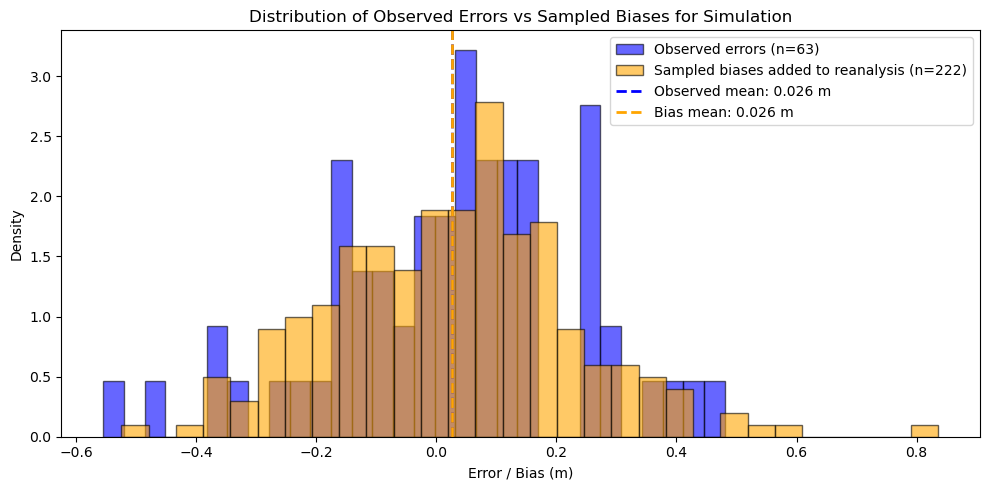


Observed errors: mean=0.026, std=0.209
Sampled biases:  mean=0.027, std=0.203


In [64]:
# Plot: Compare observed error distribution vs sampled biases added to reanalysis
fig, ax = plt.subplots(figsize=(10, 5))

# 1. Observed error distribution (from all snowy ICESat-2 dates)
observed_errors = error_df_all['error_median'].values
ax.hist(observed_errors, bins=30, alpha=0.6, color='blue', edgecolor='black', 
        label=f'Observed errors (n={len(observed_errors)})', density=True)

# 2. sampled error that was added to reanalysis data:
all_sampled_biases = all_biases.flatten()

ax.hist(all_sampled_biases, bins=30, alpha=0.6, color='orange', edgecolor='black',
        label=f'Sampled biases added to reanalysis (n={len(all_sampled_biases)})', density=True)

# Add vertical lines for means
ax.axvline(observed_errors.mean(), color='blue', linestyle='--', lw=2, label=f'Observed mean: {observed_errors.mean():.3f} m')
ax.axvline(bias_mean, color='orange', linestyle='--', lw=2, label=f'Bias mean: {bias_mean:.3f} m')

ax.set_xlabel('Error / Bias (m)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Observed Errors vs Sampled Biases for Simulation')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print summary stats
print(f"\nObserved errors: mean={observed_errors.mean():.3f}, std={observed_errors.std():.3f}")
print(f"Sampled biases:  mean={all_sampled_biases.mean():.3f}, std={all_sampled_biases.std():.3f}")

In [65]:
medians_by_date

,adjusted_date,icesat2_median,wy_1985,wy_1986,wy_1987,wy_1988,wy_1989,wy_1990,wy_1991,wy_1992,...,sim_is2_2012,sim_is2_2013,sim_is2_2014,sim_is2_2015,sim_is2_2016,sim_is2_2017,sim_is2_2018,sim_is2_2019,sim_is2_2020,sim_is2_2021
0,2021-04-01,1.312578,1.924723,2.634298,1.223753,0.644560,1.618922,0.600869,1.817257,1.509542,...,1.028335,0.833647,0.801787,-0.094911,1.743880,2.999090,0.855430,2.757786,0.730929,1.119609
1,2021-04-03,0.426210,1.653203,2.350982,0.935556,0.424587,1.058059,0.478602,1.831300,1.171965,...,0.891145,0.824049,0.531173,0.239726,1.058599,2.108835,0.950289,2.782643,0.685084,0.856302
2,2021-04-05,1.251126,1.407565,2.180916,0.796316,0.383399,1.414029,0.802161,1.655303,0.791767,...,0.707007,0.741373,0.800789,0.006215,1.528718,3.082866,0.923400,3.014164,1.442381,0.584736
3,2021-04-07,0.365464,1.426223,2.833164,0.958263,0.400653,0.977605,0.393353,1.611680,1.234875,...,1.042871,0.249765,0.639097,0.310587,0.628908,2.488251,0.951931,2.615324,0.905177,0.278918
4,2021-04-11,0.529329,0.976529,1.977536,0.543480,0.165229,0.653596,0.386917,1.293431,0.507595,...,0.687472,0.601237,0.733438,-0.016076,1.682751,2.701019,0.354254,2.125143,1.341574,0.528469
5,2021-04-13,0.485709,0.834045,1.132305,0.321477,0.176122,0.649324,0.313260,1.183276,0.458485,...,1.271118,0.353876,-0.025941,0.185694,0.602891,1.935960,0.277044,1.929566,1.380991,0.046204


In [66]:
medians_by_date.to_pickle('../data/icesat2/simulated_icesat2.pkl')

## Point-Level ICESat-2 Simulation
Instead of simulating daily medians, simulate individual ICESat-2 points by characterizing and adding point-level error to the reanalysis data sampled at each point location.

In [17]:
fn_atl06sr = '../data/icesat2/sampled_reanalysis_cherrypicked_tracks.pkl'
atl06sr_sampled = pickle.load(open(fn_atl06sr, 'rb'))

In [13]:
# Characterize point-level error between ICESat-2 and reanalysis
# Using the spring season subset (March 1 - May 31)

gdf_spring = atl06sr_gdf_snowy_100[
    (atl06sr_gdf_snowy_100['acqdate_dt'].dt.month >= 3) & 
    (atl06sr_gdf_snowy_100['acqdate_dt'].dt.month <= 5)
].copy()

# Calculate point-level error: ICESat-2 snow depth - reanalysis snow depth
gdf_spring['point_error'] = gdf_spring['icesat2_3dep_dif'] - gdf_spring['reanalysis_sd']

# Point-level error statistics
point_bias = gdf_spring['point_error'].median()
point_mean = gdf_spring['point_error'].mean()
point_std = gdf_spring['point_error'].std()
point_mae = gdf_spring['point_error'].abs().mean()

print("=" * 60)
print("POINT-LEVEL ERROR STATISTICS (ICESat-2 - Reanalysis)")
print("=" * 60)
print(f"\nTotal points: {len(gdf_spring):,}")
print(f"Mean Error:   {point_mean:.3f} m")
print(f"Median Error: {point_bias:.3f} m")
print(f"Std of Error: {point_std:.3f} m")
print(f"MAE:          {point_mae:.3f} m")
print(f"Min/Max:      {gdf_spring['point_error'].min():.3f} / {gdf_spring['point_error'].max():.3f} m")
print(f"\nPercentiles:")
for p in [5, 25, 50, 75, 95]:
    print(f"  P{p}: {gdf_spring['point_error'].quantile(p/100):.3f} m")

POINT-LEVEL ERROR STATISTICS (ICESat-2 - Reanalysis)

Total points: 369,181
Mean Error:   -0.132 m
Median Error: -0.042 m
Std of Error: 1.385 m
MAE:          0.958 m
Min/Max:      -23.380 / 13.919 m

Percentiles:
  P5: -2.365 m
  P25: -0.778 m
  P50: -0.042 m
  P75: 0.620 m
  P95: 1.846 m


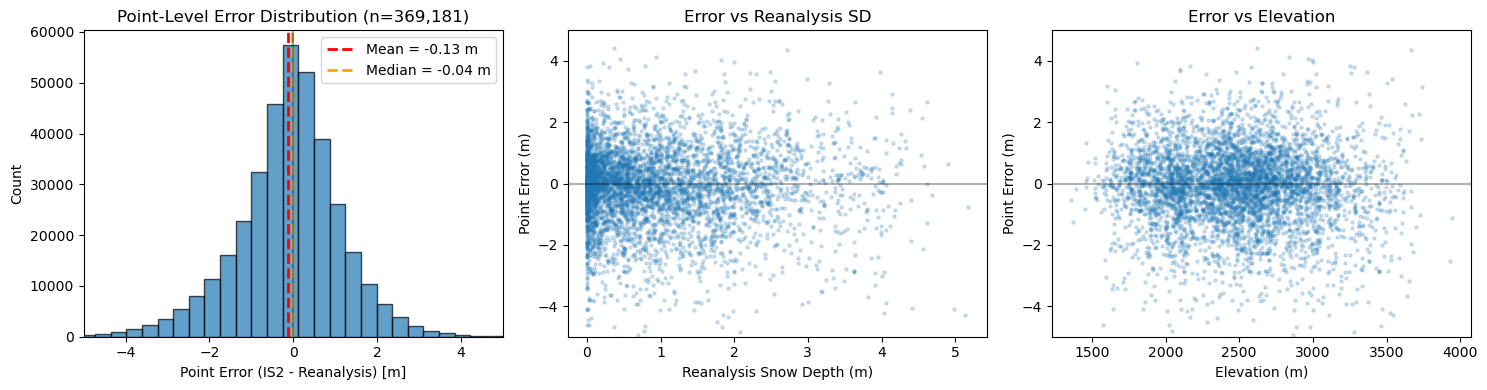


Comparison: Daily Median vs Point-Level Error
  Daily median error std:  0.210 m
  Point-level error std:   1.385 m
  Ratio (point/daily):     6.59x


In [14]:
# Visualize point-level error distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of point-level errors
axes[0].hist(gdf_spring['point_error'], bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(point_mean, color='red', linestyle='--', lw=2, label=f'Mean = {point_mean:.2f} m')
axes[0].axvline(point_bias, color='orange', linestyle='--', lw=2, label=f'Median = {point_bias:.2f} m')
axes[0].axvline(0, color='black', linestyle='-', alpha=0.3)
axes[0].set_xlabel('Point Error (IS2 - Reanalysis) [m]')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Point-Level Error Distribution (n={len(gdf_spring):,})')
axes[0].set_xlim(-5, 5)
axes[0].legend()

# Error vs reanalysis SD (heteroscedasticity check)
sample_idx = np.random.choice(len(gdf_spring), min(5000, len(gdf_spring)), replace=False)
sample = gdf_spring.iloc[sample_idx]
axes[1].scatter(sample['reanalysis_sd'], sample['point_error'], alpha=0.2, s=5)
axes[1].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Reanalysis Snow Depth (m)')
axes[1].set_ylabel('Point Error (m)')
axes[1].set_title('Error vs Reanalysis SD')
axes[1].set_ylim(-5, 5)

# Error vs elevation
axes[2].scatter(sample['3dep.value'], sample['point_error'], alpha=0.2, s=5)
axes[2].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[2].set_xlabel('Elevation (m)')
axes[2].set_ylabel('Point Error (m)')
axes[2].set_title('Error vs Elevation')
axes[2].set_ylim(-5, 5)

plt.tight_layout()
plt.show()

# Compare to daily median error distribution
print(f"\nComparison: Daily Median vs Point-Level Error")
print(f"  Daily median error std:  {error_df_all['error_median'].std():.3f} m")
print(f"  Point-level error std:   {point_std:.3f} m")
print(f"  Ratio (point/daily):     {point_std / error_df_all['error_median'].std():.2f}x")

In [18]:
# Generate simulated ICESat-2 point data for each historical year
# Each point gets an independently sampled error from the point-level error distribution

# Use the cherry-picked subset with reanalysis already sampled at each point
atl06sr_points = atl06sr_sampled.copy()

# Get the water year columns (reanalysis SD at each point)
wy_cols = [col for col in atl06sr_points.columns if col.startswith('wy_')]

# Number of points
n_points = len(atl06sr_points)
n_years = len(wy_cols)

print(f"Generating point-level simulated ICESat-2 data")
print(f"  Number of points: {n_points:,}")
print(f"  Number of years: {n_years}")
print(f"  Total values to simulate: {n_points * n_years:,}")

# Sample errors from the observed point-level error distribution
# Using the empirical distribution (sampling with replacement from observed errors)
np.random.seed(42)

# Option 1: Sample from empirical distribution
empirical_errors = gdf_spring['point_error'].values

# Option 2: Sample from fitted normal distribution
# Uncomment to use parametric sampling instead
# sampled_errors = np.random.normal(point_mean, point_std, (n_points, n_years))

for i, year_col in enumerate(wy_cols):
    year = year_col.replace('wy_', '')
    
    # Sample n_points errors from the empirical distribution
    sampled_errors = np.random.choice(empirical_errors, size=n_points, replace=True)
    
    # Simulated IS2 = reanalysis SD + sampled error
    atl06sr_points[f'sim_is2_{year}'] = atl06sr_points[year_col] + sampled_errors

sim_cols = [col for col in atl06sr_points.columns if col.startswith('sim_is2_')]
print(f"\nGenerated {len(sim_cols)} simulated ICESat-2 columns")
print(f"Dataframe shape: {atl06sr_points.shape}")
print(f"New columns: {sim_cols[:5]}... {sim_cols[-3:]}")

Generating point-level simulated ICESat-2 data
  Number of points: 70,070
  Number of years: 37
  Total values to simulate: 2,592,590

Generated 37 simulated ICESat-2 columns
Dataframe shape: (70070, 125)
New columns: ['sim_is2_1985', 'sim_is2_1986', 'sim_is2_1987', 'sim_is2_1988', 'sim_is2_1989']... ['sim_is2_2019', 'sim_is2_2020', 'sim_is2_2021']


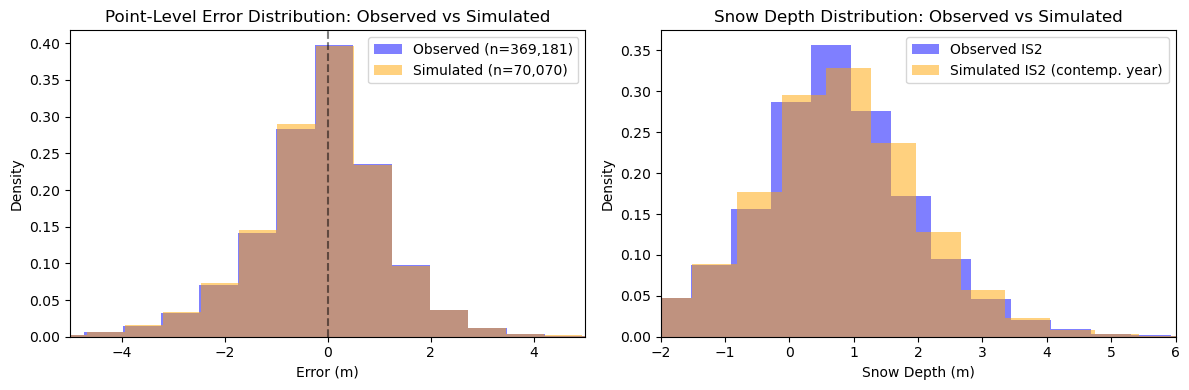

Observed IS2:  mean=0.631, std=1.404 m
Simulated IS2: mean=0.657, std=1.503 m


In [19]:
# Validate: Compare distribution of actual errors vs simulated errors
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Compare error distributions
# Calculate simulated errors (sim_is2 - reanalysis) for a sample year
sample_year = 2019
sim_errors = atl06sr_points[f'sim_is2_{sample_year}'] - atl06sr_points[f'wy_{sample_year}']

axes[0].hist(gdf_spring['point_error'], bins=50, alpha=0.5, color='blue', 
             label=f'Observed (n={len(gdf_spring):,})', density=True)
axes[0].hist(sim_errors, bins=50, alpha=0.5, color='orange', 
             label=f'Simulated (n={len(sim_errors):,})', density=True)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Error (m)')
axes[0].set_ylabel('Density')
axes[0].set_title('Point-Level Error Distribution: Observed vs Simulated')
axes[0].legend()
axes[0].set_xlim(-5, 5)

# 2. Compare simulated vs observed IS2 values (for the actual observation year)
# Get the observed ICESat-2 values and the simulated values for 2020/2021
mask_2020 = atl06sr_points['acqdate_dt'].dt.year == 2020
mask_2021 = atl06sr_points['acqdate_dt'].dt.year == 2021

observed_is2 = atl06sr_points['icesat2_3dep_dif'].values
sim_is2_contemp = np.where(mask_2020, atl06sr_points['sim_is2_2020'], atl06sr_points['sim_is2_2021'])

axes[1].hist(observed_is2, bins=50, alpha=0.5, color='blue', label='Observed IS2', density=True)
axes[1].hist(sim_is2_contemp, bins=50, alpha=0.5, color='orange', label='Simulated IS2 (contemp. year)', density=True)
axes[1].set_xlabel('Snow Depth (m)')
axes[1].set_ylabel('Density')
axes[1].set_title('Snow Depth Distribution: Observed vs Simulated')
axes[1].legend()
axes[1].set_xlim(-2, 6)

plt.tight_layout()
plt.show()

print(f"Observed IS2:  mean={observed_is2.mean():.3f}, std={observed_is2.std():.3f} m")
print(f"Simulated IS2: mean={np.nanmean(sim_is2_contemp):.3f}, std={np.nanstd(sim_is2_contemp):.3f} m")

In [20]:
# Preview the point-level simulated data
display_cols = ['adjusted_date', 'icesat2_3dep_dif', '3dep.value', 'reanalysis_sd', 
                'wy_2019', 'wy_2020', 'wy_2021', 'sim_is2_2019', 'sim_is2_2020', 'sim_is2_2021']
atl06sr_points[display_cols].head(10)

,adjusted_date,icesat2_3dep_dif,3dep.value,reanalysis_sd,wy_2019,wy_2020,wy_2021,sim_is2_2019,sim_is2_2020,sim_is2_2021
time_ns,,,,,,,,,,
2020-04-03 09:56:50.216293120,2021-04-03,0.962641,2724.638922,0.0206,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-03 09:56:50.213481984,2021-04-03,1.240672,2729.237111,0.0206,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-03 09:56:50.210669056,2021-04-03,1.556051,2732.365336,0.0206,2.053229,0.262605,0.227323,2.953200,-1.938787,0.187249
2020-04-03 09:56:50.207858432,2021-04-03,1.894619,2735.017246,0.0206,2.089458,0.297033,0.241020,-2.652750,0.290355,-0.280027
2020-04-03 09:56:49.868930304,2021-04-03,-0.456278,2737.584940,0.0206,2.032946,0.167695,0.176224,2.481316,1.115841,0.686163
2020-04-03 09:56:49.860496896,2021-04-03,0.128630,2748.507356,0.0206,2.147450,0.305625,0.223786,1.774564,-1.958478,-1.589575
2020-04-03 09:56:49.857684992,2021-04-03,0.597116,2749.800833,0.0206,2.185750,0.352441,0.239784,2.127054,0.654662,-0.360727
2020-04-03 09:56:49.854875648,2021-04-03,0.760423,2749.111404,0.0206,2.224095,0.399650,0.255833,2.021617,1.637526,1.271340
2020-04-03 09:56:50.205045248,2021-04-03,2.142359,2736.802953,0.0206,2.125727,0.331833,0.254760,1.371964,0.642245,-1.220199


In [21]:
# Save the point-level simulated ICESat-2 data
output_path = '../data/icesat2/simulated_icesat2_points.pkl'
atl06sr_points.to_pickle(output_path)
print(f"Saved point-level simulated data to {output_path}")
print(f"Shape: {atl06sr_points.shape}")

Saved point-level simulated data to ../data/icesat2/simulated_icesat2_points.pkl
Shape: (70070, 125)
